# 08 - Active learning simulation

Simulates a low-label discovery setting: most labels are "hidden", and at each round a strategy picks which proteins to label next. We compare three strategies on a **fixed test set**:

- **random** - pick at random (baseline to beat)
- **uncertainty** - pick where the model is least confident (1 - max prob)
- **diversity** - uncertain AND spread out (cluster candidates, pick representatives)

Model: LogisticRegression on ESM embeddings (fast to retrain many times, gives probabilities for uncertainty). All logic lives in `src/active_learning.py`; this notebook just sets up the data splits and runs the experiment.

## 1. Setup & load embeddings + labels

In [2]:
import sys
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

PROJECT_ROOT = Path.cwd().resolve()
if PROJECT_ROOT.name == "notebooks":
    PROJECT_ROOT = PROJECT_ROOT.parent
PROCESSED_DIR = PROJECT_ROOT / "data" / "processed"
EMB_DIR       = PROJECT_ROOT / "data" / "embeddings"
RESULTS_DIR   = PROJECT_ROOT / "results"
SRC_DIR       = PROJECT_ROOT / "src"
(RESULTS_DIR / "figures").mkdir(parents=True, exist_ok=True)

sys.path.insert(0, str(SRC_DIR))
from embeddings import load_embeddings
import active_learning as AL
import train as T

CLASS_ORDER  = ["enzyme", "dna_rna_binding", "receptor", "transporter", "structural", "other"]
RANDOM_STATE = T.RANDOM_STATE


In [3]:
# Align embeddings with labels (same dedup logic as previous notebooks).
feats = pd.read_csv(PROCESSED_DIR / "sequence_features.csv", index_col="accession")
feats.index = feats.index.astype(str)
emb, emb_meta = load_embeddings(EMB_DIR)
emb_df = pd.DataFrame(emb, index=emb_meta["accession"].astype(str))

src_df = pd.read_csv(PROCESSED_DIR / "labeled_dataset.csv")
keep_acc = src_df.drop_duplicates(subset="sequence", keep="first")["accession"].astype(str)
feats = feats.loc[feats.index.intersection(keep_acc)]
order = list(feats.index.intersection(emb_df.index))

y = feats.loc[order, "function_class"].to_numpy()
X = emb_df.loc[order].to_numpy()
print(f"Aligned {len(order)} proteins, embedding dim {X.shape[1]}")


Aligned 8513 proteins, embedding dim 1280


## 2. Three-way split: test / seed / pool

- **Test (20%)** - held out entirely, never revealed. The fixed yardstick.
- From the remaining 80%:
  - **Seed (100, stratified)** - the labels we "start with".
  - **Pool (the rest)** - labels known but treated as hidden; strategies pick from here.

Stratifying the seed ensures every class is represented from round 0.

In [4]:
from sklearn.model_selection import train_test_split

# Test set: fixed, never touched during the experiment.
idx = np.arange(len(order))
trainpool_idx, test_idx = train_test_split(
    idx, test_size=0.20, stratify=y, random_state=RANDOM_STATE
)

# Seed (100, stratified) vs pool, taken from the train+pool portion.
seed_idx, pool_idx = train_test_split(
    trainpool_idx, train_size=100, stratify=y[trainpool_idx], random_state=RANDOM_STATE
)

X_seed, y_seed = X[seed_idx], y[seed_idx]
X_pool, y_pool = X[pool_idx], y[pool_idx]
X_test, y_test = X[test_idx], y[test_idx]

print(f"Seed: {len(y_seed)}   Pool: {len(y_pool)}   Test: {len(y_test)}")
print("Seed class counts:", dict(zip(*np.unique(y_seed, return_counts=True))))


Seed: 100   Pool: 6710   Test: 1703
Seed class counts: {'dna_rna_binding': np.int64(20), 'enzyme': np.int64(32), 'other': np.int64(15), 'receptor': np.int64(9), 'structural': np.int64(9), 'transporter': np.int64(15)}


## 3. Run the experiment

10 rounds of +100 labels each (100 -> 1100 labeled). Random sampling is run with
**5 seeds** because its result varies run-to-run; uncertainty and diversity are
deterministic given the model, so one run each is enough (we still vary the seed
for the diversity clustering).

In [5]:
N_ROUNDS    = 10
N_PER_ROUND = 100
SEEDS       = [0, 1, 2, 3, 4]   # for averaging the random baseline

def run_one(strategy_name, random_state):
    return AL.run_active_learning(
        AL.STRATEGIES[strategy_name],
        X_seed, y_seed, X_pool, y_pool, X_test, y_test,
        n_rounds=N_ROUNDS, n_per_round=N_PER_ROUND, random_state=random_state,
    )

records = []

# Random: average over seeds.
for s in SEEDS:
    for row in run_one("random", s):
        records.append({"strategy": "random", "seed": s, **row})

# Uncertainty and diversity: one run each (diversity's clustering uses the seed).
for row in run_one("uncertainty", RANDOM_STATE):
    records.append({"strategy": "uncertainty", "seed": RANDOM_STATE, **row})

for row in run_one("diversity", RANDOM_STATE):
    records.append({"strategy": "diversity", "seed": RANDOM_STATE, **row})

results = pd.DataFrame(records)
print("Done.")
results.head()


Done.


,strategy,seed,n_labeled,test_macro_f1
0,random,0,100,0.4996
1,random,0,200,0.5597
2,random,0,300,0.5870
3,random,0,400,0.5888
4,random,0,500,0.6151


## 4. Save results

In [7]:
# Split out per-strategy CSVs (matches the project plan's filenames).
for name in ["random", "uncertainty", "diversity"]:
    sub = results[results["strategy"] == name]
    sub.to_csv(RESULTS_DIR / f"active_learning_{name}.csv", index=False)
results.to_csv(RESULTS_DIR / "active_learning_all.csv", index=False)
print("Saved per-strategy CSVs + combined.")


Saved per-strategy CSVs + combined.


## 5. Learning curves

x = number of labeled proteins, y = test macro-F1, one line per strategy. For
random we plot the mean across seeds with a shaded band for +/- 1 std.

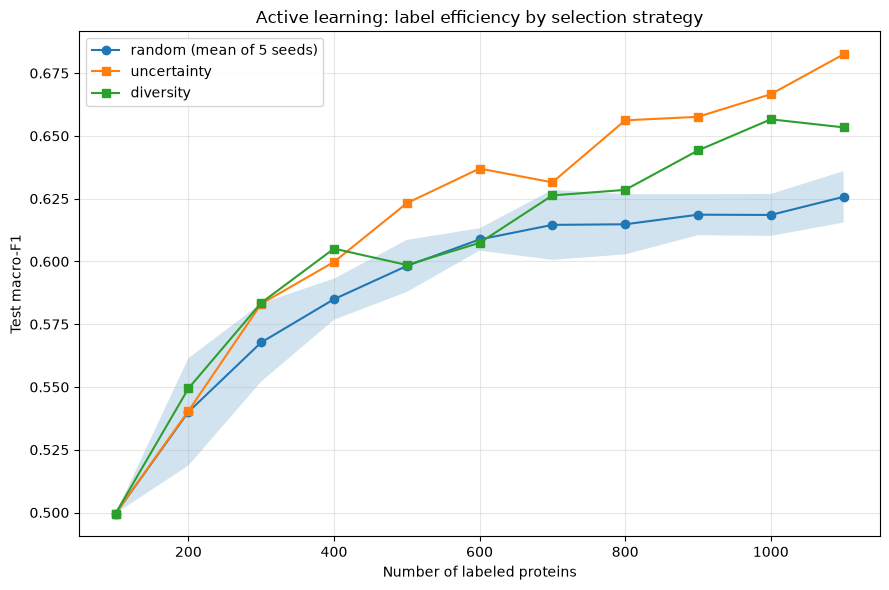

In [8]:
fig, ax = plt.subplots(figsize=(9, 6))

# Random: mean + std band across seeds.
rand = results[results["strategy"] == "random"].groupby("n_labeled")["test_macro_f1"]
rand_mean, rand_std = rand.mean(), rand.std()
ax.plot(rand_mean.index, rand_mean.values, marker="o", label="random (mean of 5 seeds)")
ax.fill_between(rand_mean.index, rand_mean - rand_std, rand_mean + rand_std, alpha=0.2)

# Uncertainty and diversity: single lines.
for name in ["uncertainty", "diversity"]:
    sub = results[results["strategy"] == name].sort_values("n_labeled")
    ax.plot(sub["n_labeled"], sub["test_macro_f1"], marker="s", label=name)

ax.set_xlabel("Number of labeled proteins")
ax.set_ylabel("Test macro-F1")
ax.set_title("Active learning: label efficiency by selection strategy")
ax.legend()
ax.grid(alpha=0.3)
plt.tight_layout()
fig.savefig(RESULTS_DIR / "figures" / "active_learning_curve.png", dpi=150, bbox_inches="tight")
plt.show()


## 6. Quantify: labels saved to reach a target

A concrete way to read the curves: pick a target macro-F1 and ask how many labels
each strategy needed to first reach it. Fewer labels = more efficient.

In [10]:
def labels_to_reach(strategy_name, target):
    sub = results[results["strategy"] == strategy_name]
    # average across seeds at each label count, then find first >= target
    avg = sub.groupby("n_labeled")["test_macro_f1"].mean()
    hit = avg[avg >= target]
    return int(hit.index[0]) if len(hit) else None

target = 0.625   
print(f"Labels needed to first reach macro-F1 >= {target}:")
for name in ["random", "uncertainty", "diversity"]:
    n = labels_to_reach(name, target)
    print(f"  {name:12s}: {n if n else 'not reached'}")


Labels needed to first reach macro-F1 >= 0.625:
  random      : 1100
  uncertainty : 600
  diversity   : 700


## 7. Interpretation

- **Smart selection beat random**: From ~400 labels onward, uncertainty and diversity sampling rose clearly above the random baseline's ±1 std band and stayed there — the gain comes from which proteins were selected, not chance.

- **Quantified efficiency** : To first reach macro-F1 ≥ 0.625: uncertainty needed 600 labels, diversity 700, random 1100. Uncertainty hit the target with ~45% fewer labels than random (500 saved) — in the discovery framing, 500 fewer wet-lab characterizations for equivalent model quality. (Threshold set at random's ceiling so the comparison isn't cherry-picked.)

- **Plain uncertainty won**: diversity wasn't worth it. The two smart strategies tracked closely, but uncertainty was both simpler and more efficient (600 vs 700 labels to target; ~0.68 vs ~0.65 at the end). The diversity clustering added no value here — likely because the deduplicated pool wasn't redundant enough for diversity-aware selection to help.

- **Early rounds overlap** : Below ~300 labels all strategies are tied: with little data the model's uncertainty estimates are unreliable, so smart selection can't yet help. Separation emerges only once the model's confidence becomes meaningful — expected active-learning behavior.

- **_Caveats_**: uncertainty came from LogReg probabilities, which aren't perfectly calibrated; the smart strategies are single runs, so round-to-round wiggles (e.g. diversity's dip at 700) are noise, not trend.

- **_Takeaway_**: label selection matters here — uncertainty sampling delivered a real ~45% label-efficiency gain over random, while the more elaborate diversity method wasn't justified by the data. Choosing the simpler effective method is the honest conclusion.
